# EDA: рекомендации резюме к вакансии

Задача: по опубликованной вакансии рекомендовать релевантные резюме.

вакансия рассматривается как `query`, резюме как набор документов, а `applies` как positive-only сигнал исторического отклика

Цель EDA - понять связность данных, разреженность позитивных пар, риски утечек, пригодность жестких фильтров и силу embedding baseline. Данные берутся только из `data/aaa-out` и описания проекта `desciption.md`.

In [1]:
import gc
import sys
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"pyarrow: {pa.__version__}")

Python: 3.10.11
pandas: 2.3.2
pyarrow: 24.0.0


In [ ]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "aaa-out").exists():
            return candidate
    raise FileNotFoundError(
        "Не нашел папку data/aaa-out ни в текущей директории, ни выше по дереву"
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "aaa-out"
DESCRIPTION_PATH = PROJECT_ROOT / "desciption.md"
DATA_CARD_PATH = DATA_DIR / "DATA_CARD.md"

files = {
    "cv": DATA_DIR / "cv.parquet",
    "vacancies": DATA_DIR / "vacancies.parquet",
    "applies": DATA_DIR / "applies.parquet",
    "cv_embeddings": DATA_DIR / "cv_embeddings.parquet",
    "vacancies_embeddings": DATA_DIR / "vacancies_embeddings.parquet",
}

missing_files = [str(path) for path in files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Не найдены файлы: {missing_files}")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")

## Постановка задачи

Исторические отклики можно использовать как позитивные пары `vacancy_id_hash` -> `cv_id_hash`. **Негативов в данных нет**: отсутствие отклика не означает нерелевантность, поэтому для обучения их нужно конструировать отдельно.

Практический пайплайн выглядит как retrieval + ranking:

1. Сначала быстро получить кандидатов по embeddings и мягким структурным признакам.
2. Затем переранжировать кандидатов более тяжелой моделью.
3. Валидацию делать так, чтобы не подсмотреть в будущее и не превратить технические даты в утечку.

In [3]:
cv = pd.read_parquet(files['cv'])
vacancies = pd.read_parquet(files['vacancies'])
applies = pd.read_parquet(files['applies'])
cv_embeddings = pd.read_parquet(files['cv_embeddings'])
vacancies_embeddings = pd.read_parquet(files['vacancies_embeddings'])
display(cv.head())
display(vacancies.head())
display(applies.head())
display(cv_embeddings.head())
display(vacancies_embeddings.head())

,cv_id_hash,user_id_hash,created_at_jittered,profession,group_profession,business_category,sfera,experience_bucket,education,federal_district,salary_bucketed,employment_type,schedule
0,415a8c99688dd69f,af0e0783ad47b35c,2024-12-29,другая,другое,Другое,"без опыта, студенты",<NA>,среднее специальное,Приволжский федеральный округ,NaN,смешанный,полный день
1,2ece71369d0e4c71,bbbd6d3ee48fd130,2025-01-01,другая,другое,Другое,"без опыта, студенты",без опыта,среднее,Сибирский федеральный округ,NaN,только подработка,свободный график
2,2c482ffa89128389,42a6d928d4e62937,2025-01-01,other,"сотрудники охраны, контроля и госорганов",РиЛ,консультирование,есть опыт,среднее специальное,Северо-Западный федеральный округ,47816.0,смешанный,полный день
3,dea8751d8348c9e9,cb47e93883398783,2026-05-07,менеджер по продажам,специалисты по продажам,Офисные,управление персоналом,есть опыт,высшее,Центральный федеральный округ,102453.0,только подработка,неполный день
4,ff4e335e41e5251f,f58d0670e53aa0cc,2024-12-31,охранник,"сотрудники охраны, контроля и госорганов",РиЛ,"охрана, безопасность",<NA>,среднее специальное,Центральный федеральный округ,NaN,только основная работа,сменный график


,vacancy_id_hash,employer_id_hash,published_at_jittered,profession,group_profession,business_category,sfera,experience,schedule,employment_type,education_level
0,9acbdf658912c3ef,ada83777917f2149,2025-11-08,упаковщик,работники складов,РиЛ,банковские и финансовые услуги,без опыта,гибкий,частичная занятость,<NA>
1,2c39aeaa9410e4a7,72cad866d3754984,2025-04-06,менеджер по работе с клиентами,специалисты по продажам,Офисные,розничная и оптовая торговля,без опыта,гибкий,частичная занятость,не имеет значения
2,5c408af446743493,34f8f0e9410ba769,2026-01-04,фасовщик,работники складов,РиЛ,бытовые и персональные услуги,без опыта,сменный,частичная занятость,<NA>
3,91ca6ac6dcf40480,f307cd1e3ef3f567,2026-03-19,грузчик,работники складов,РиЛ,бытовые и персональные услуги,без опыта,гибкий,частичная занятость,<NA>
4,8507631490af832d,6f7ce0ac71a81dca,2025-08-24,водитель грузового транспорта,водители и курьеры,TTL,госслужба,без опыта,вахта,полная занятость,<NA>


,cv_id_hash,vacancy_id_hash,applied_at_jittered
0,b87888f8af1afe39,b11747a9210b036c,2026-02-16
1,b87888f8af1afe39,fac61f14fde0e2dc,2026-02-18
2,b87888f8af1afe39,c63902dc428d76d5,2026-02-15
3,b87888f8af1afe39,1813cfb89bf12dcb,2026-02-15
4,38d5e1f5b3419874,d34e429154bec9dc,2026-02-19


,cv_id_hash,embedding
0,415a8c99688dd69f,"[0.05225, -0.1074, -0.01184, -0.0569, 0.09717, 0.001518, -8.82e-05, 0.007782, -0.04712, 0.03088, -0.02478, -0.03198,..."
1,2ece71369d0e4c71,"[0.03442, -0.12354, -0.009155, -0.0498, 0.07666, -0.006287, 0.00232, 0.052, -0.04053, 0.0354, -0.01257, -0.00958, 0...."
2,2c482ffa89128389,"[0.0569, -0.1543, -0.00717, -0.02234, 0.01855, -0.0299, 0.00351, 0.04468, 0.02527, 0.0864, -0.02087, -0.01282, 0.115..."
3,dea8751d8348c9e9,"[0.04565, -0.06885, -0.01056, 0.013, -0.00824, -0.04565, 0.03296, -0.002747, 0.00592, 0.026, 0.02344, 0.04395, 0.074..."
4,ff4e335e41e5251f,"[0.02283, -0.1426, -0.00209, -0.03296, 0.05273, -0.02466, 0.0141, 0.07764, 0.02832, 0.0437, -0.05615, 0.006226, 0.10..."


,vacancy_id_hash,embedding
0,9acbdf658912c3ef,"[0.00403, -0.0564, -0.01001, -0.07324, 0.021, -0.000269, 0.00479, 0.04517, 0.01349, 0.06006, -0.002563, 0.01105, 0.0..."
1,2c39aeaa9410e4a7,"[0.003586, -0.0227, -0.01019, -0.04028, 0.01929, -0.02502, -0.00644, 0.031, -0.0015335, 0.009094, 0.01563, 0.03857, ..."
2,5c408af446743493,"[0.01685, -0.04932, -0.01282, -0.0752, -0.001259, 0.01892, 0.007538, 0.02417, 0.02344, 0.0376, -0.009155, 0.01355, 0..."
3,91ca6ac6dcf40480,"[0.0315, -0.0459, -0.01044, -0.0669, -0.015564, 0.01941, 0.0232, 0.04224, 0.012024, 0.06934, 0.00653, 0.0332, 0.0722..."
4,8507631490af832d,"[0.03394, -0.1094, -0.01184, -0.0003834, 0.01794, -0.03394, -0.01489, 0.03735, -0.06885, 0.084, -0.0293, 0.05078, 0...."


In [4]:
tables = {
    'cv': cv,
    'vacancies': vacancies,
    'applies': applies,
    'cv_embeddings': cv_embeddings,
    'vacancies_embeddings': vacancies_embeddings,
}

shape_summary = pd.DataFrame(
    [{'table': name, 'rows': len(df), 'columns': df.shape[1]} for name, df in tables.items()]
)
display(shape_summary)

for name, df in tables.items():
    print(f'\n{name}')
    display(pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str).to_numpy()}))

,table,rows,columns
0,cv,7976,13
1,vacancies,9957,11
2,applies,56809,3
3,cv_embeddings,7976,2
4,vacancies_embeddings,9957,2



cv


,column,dtype
0,cv_id_hash,object
1,user_id_hash,object
2,created_at_jittered,datetime64[ms]
3,profession,string
4,group_profession,string
5,business_category,object
6,sfera,string
7,experience_bucket,string
8,education,string
9,federal_district,object



vacancies


,column,dtype
0,vacancy_id_hash,object
1,employer_id_hash,object
2,published_at_jittered,datetime64[us]
3,profession,string
4,group_profession,string
5,business_category,object
6,sfera,string
7,experience,string
8,schedule,string
9,employment_type,string


...

,column,dtype
0,cv_id_hash,object
1,vacancy_id_hash,object
2,applied_at_jittered,datetime64[us]



cv_embeddings


,column,dtype
0,cv_id_hash,object
1,embedding,object



vacancies_embeddings


,column,dtype
0,vacancy_id_hash,object
1,embedding,object


In [5]:
key_checks = pd.DataFrame([
    {
        'table': 'cv',
        'key': 'cv_id_hash',
        'rows': len(cv),
        'unique_keys': cv['cv_id_hash'].nunique(),
        'duplicate_keys': int(cv['cv_id_hash'].duplicated().sum()),
    },
    {
        'table': 'vacancies',
        'key': 'vacancy_id_hash',
        'rows': len(vacancies),
        'unique_keys': vacancies['vacancy_id_hash'].nunique(),
        'duplicate_keys': int(vacancies['vacancy_id_hash'].duplicated().sum()),
    },
    {
        'table': 'applies',
        'key': 'cv_id_hash + vacancy_id_hash',
        'rows': len(applies),
        'unique_keys': applies[['cv_id_hash', 'vacancy_id_hash']].drop_duplicates().shape[0],
        'duplicate_keys': int(applies.duplicated(['cv_id_hash', 'vacancy_id_hash']).sum()),
    },
])
display(key_checks)

missing_parts = []
for name, df in {'cv': cv, 'vacancies': vacancies, 'applies': applies}.items():
    part = df.isna().sum().rename('missing').reset_index().rename(columns={'index': 'column'})
    part['table'] = name
    part['missing_pct'] = part['missing'] / len(df) * 100
    missing_parts.append(part[['table', 'column', 'missing', 'missing_pct']])
missing_summary = pd.concat(missing_parts, ignore_index=True)
display(missing_summary[missing_summary['missing'] > 0].sort_values(['table', 'missing_pct'], ascending=[True, False]))

,table,key,rows,unique_keys,duplicate_keys
0,cv,cv_id_hash,7976,7976,0
1,vacancies,vacancy_id_hash,9957,9957,0
2,applies,cv_id_hash + vacancy_id_hash,56809,56809,0


,table,column,missing,missing_pct
10,cv,salary_bucketed,5747,72.053661
7,cv,experience_bucket,1307,16.386660
23,vacancies,education_level,9106,91.453249


In [6]:
cv_ids = set(cv['cv_id_hash'])
vacancy_ids = set(vacancies['vacancy_id_hash'])

connectivity = pd.DataFrame([
    {
        'check': 'applies.cv_id_hash есть в cv',
        'missing_rows': int((~applies['cv_id_hash'].isin(cv_ids)).sum()),
        'missing_pct': (~applies['cv_id_hash'].isin(cv_ids)).mean() * 100,
    },
    {
        'check': 'applies.vacancy_id_hash есть в vacancies',
        'missing_rows': int((~applies['vacancy_id_hash'].isin(vacancy_ids)).sum()),
        'missing_pct': (~applies['vacancy_id_hash'].isin(vacancy_ids)).mean() * 100,
    },
    {
        'check': 'cv_embeddings.cv_id_hash есть в cv',
        'missing_rows': int((~cv_embeddings['cv_id_hash'].isin(cv_ids)).sum()),
        'missing_pct': (~cv_embeddings['cv_id_hash'].isin(cv_ids)).mean() * 100,
    },
    {
        'check': 'vacancies_embeddings.vacancy_id_hash есть в vacancies',
        'missing_rows': int((~vacancies_embeddings['vacancy_id_hash'].isin(vacancy_ids)).sum()),
        'missing_pct': (~vacancies_embeddings['vacancy_id_hash'].isin(vacancy_ids)).mean() * 100,
    },
])
display(connectivity)

positive_density = len(applies.drop_duplicates(['cv_id_hash', 'vacancy_id_hash'])) / (cv['cv_id_hash'].nunique() * vacancies['vacancy_id_hash'].nunique()) * 100
coverage = pd.DataFrame([
    {
        'entity': 'vacancies',
        'covered_by_applies': applies['vacancy_id_hash'].nunique(),
        'total': vacancies['vacancy_id_hash'].nunique(),
        'coverage_pct': applies['vacancy_id_hash'].nunique() / vacancies['vacancy_id_hash'].nunique() * 100,
    },
    {
        'entity': 'cv',
        'covered_by_applies': applies['cv_id_hash'].nunique(),
        'total': cv['cv_id_hash'].nunique(),
        'coverage_pct': applies['cv_id_hash'].nunique() / cv['cv_id_hash'].nunique() * 100,
    },
])
print(f'Плотность позитивных пар: {positive_density:.4f}% (доля откликов среди всех теоретически возможных пар vacancy-cv)')
display(coverage)

,check,missing_rows,missing_pct
0,applies.cv_id_hash есть в cv,0,0.0
1,applies.vacancy_id_hash есть в vacancies,0,0.0
2,cv_embeddings.cv_id_hash есть в cv,0,0.0
3,vacancies_embeddings.vacancy_id_hash есть в vacancies,0,0.0


Плотность позитивных пар: 0.0715% (доля откликов среди всех теоретически возможных пар vacancy-cv)


,entity,covered_by_applies,total,coverage_pct
0,vacancies,9908,9957,99.507884
1,cv,7976,7976,100.000000


## Embeddings: форма и нормы

По Data Card embeddings сгенерированы одной моделью и L2-нормированы, поэтому cosine similarity можно считать как dot product (cosine(a, b) = dot(a, b) / (norm(a) * norm(b))
). Ниже проверяется, что размерность и нормы действительно выглядят корректно.

In [7]:
def embedding_to_matrix(df: pd.DataFrame, column: str = 'embedding') -> np.ndarray:
    lengths = df[column].map(len)
    if lengths.nunique() != 1:
        raise ValueError(f'Найдены разные размерности embeddings: {lengths.value_counts().head()}')
    return np.vstack(df[column].to_numpy()).astype('float32')


cv_matrix = embedding_to_matrix(cv_embeddings)
vacancy_matrix = embedding_to_matrix(vacancies_embeddings)

cv_norms = np.linalg.norm(cv_matrix, axis=1)
vacancy_norms = np.linalg.norm(vacancy_matrix, axis=1)
embedding_checks = pd.DataFrame([
    {
        'table': 'cv_embeddings',
        'rows': cv_matrix.shape[0],
        'dim': cv_matrix.shape[1],
        'norm_min': cv_norms.min(),
        'norm_p50': np.percentile(cv_norms, 50),
        'norm_max': cv_norms.max(),
    },
    {
        'table': 'vacancies_embeddings',
        'rows': vacancy_matrix.shape[0],
        'dim': vacancy_matrix.shape[1],
        'norm_min': vacancy_norms.min(),
        'norm_p50': np.percentile(vacancy_norms, 50),
        'norm_max': vacancy_norms.max(),
    },
])
display(embedding_checks)

,table,rows,dim,norm_min,norm_p50,norm_max
0,cv_embeddings,7976,1024,0.998048,1.000375,1.003832
1,vacancies_embeddings,9957,1024,0.998047,1.000447,1.003812


## Data quality и временные аномалии

В этом блоке отдельно смотрим пропуски в полях, которые могут стать фильтрами или признаками, а также диапазоны дат. Для рекомендательной задачи даты особенно чувствительны: если split или признаки используют информацию, которая появилась после события, оценка будет завышена.

,table,column,missing,missing_pct
0,cv,salary_bucketed,5747,72.053661
1,cv,education,0,0.000000
2,vacancies,education_level,9106,91.453249
3,cv,experience_bucket,1307,16.386660
4,vacancies,experience,0,0.000000


,field,min,max
0,cv.created_at_jittered,2024-07-04,2026-05-09
1,vacancies.published_at_jittered,2012-07-01,2026-05-07
2,applies.applied_at_jittered,2025-11-06,2026-05-09


,check,rows,pct_of_applies
0,applied_at_jittered < published_at_jittered,1450,2.552412
1,applied_at_jittered < created_at_jittered,48124,84.711929


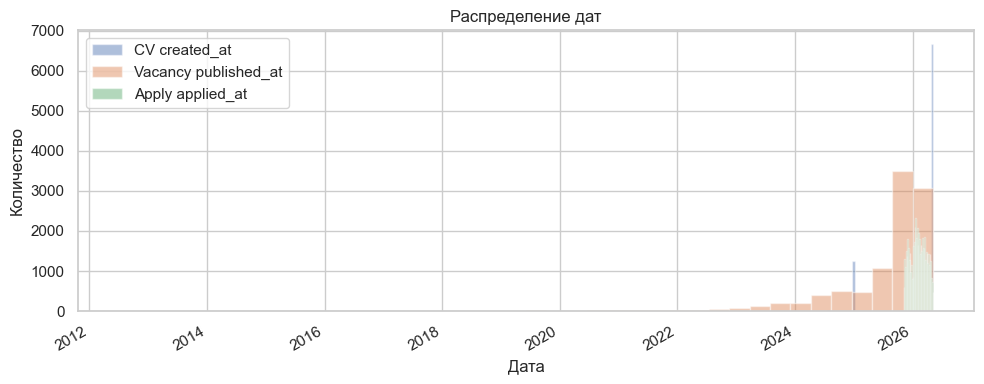

In [8]:
focus_missing = pd.DataFrame([
    {
        'table': 'cv',
        'column': 'salary_bucketed',
        'missing': int(cv['salary_bucketed'].isna().sum()),
        'missing_pct': cv['salary_bucketed'].isna().mean() * 100,
    },
    {
        'table': 'cv',
        'column': 'education',
        'missing': int(cv['education'].isna().sum()),
        'missing_pct': cv['education'].isna().mean() * 100,
    },
    {
        'table': 'vacancies',
        'column': 'education_level',
        'missing': int(vacancies['education_level'].isna().sum()),
        'missing_pct': vacancies['education_level'].isna().mean() * 100,
    },
    {
        'table': 'cv',
        'column': 'experience_bucket',
        'missing': int(cv['experience_bucket'].isna().sum()),
        'missing_pct': cv['experience_bucket'].isna().mean() * 100,
    },
    {
        'table': 'vacancies',
        'column': 'experience',
        'missing': int(vacancies['experience'].isna().sum()),
        'missing_pct': vacancies['experience'].isna().mean() * 100,
    },
])
display(focus_missing)

applies_with_dates = (
    applies
    .merge(vacancies[['vacancy_id_hash', 'published_at_jittered']], on='vacancy_id_hash', how='left')
    .merge(cv[['cv_id_hash', 'created_at_jittered']], on='cv_id_hash', how='left')
)

date_ranges = pd.DataFrame([
    {'field': 'cv.created_at_jittered', 'min': cv['created_at_jittered'].min(), 'max': cv['created_at_jittered'].max()},
    {'field': 'vacancies.published_at_jittered', 'min': vacancies['published_at_jittered'].min(), 'max': vacancies['published_at_jittered'].max()},
    {'field': 'applies.applied_at_jittered', 'min': applies['applied_at_jittered'].min(), 'max': applies['applied_at_jittered'].max()},
])
display(date_ranges)

anomalies = pd.DataFrame([
    {
        'check': 'applied_at_jittered < published_at_jittered',
        'rows': int((applies_with_dates['applied_at_jittered'] < applies_with_dates['published_at_jittered']).sum()),
        'pct_of_applies': (applies_with_dates['applied_at_jittered'] < applies_with_dates['published_at_jittered']).mean() * 100,
    },
    {
        'check': 'applied_at_jittered < created_at_jittered',
        'rows': int((applies_with_dates['applied_at_jittered'] < applies_with_dates['created_at_jittered']).sum()),
        'pct_of_applies': (applies_with_dates['applied_at_jittered'] < applies_with_dates['created_at_jittered']).mean() * 100,
    },
])
display(anomalies)

fig, ax = plt.subplots(figsize=(10, 4))
for series, label in [
    (cv['created_at_jittered'], 'CV created_at'),
    (vacancies['published_at_jittered'], 'Vacancy published_at'),
    (applies['applied_at_jittered'], 'Apply applied_at'),
]:
    ax.hist(series.dropna(), bins=40, alpha=0.45, label=label)
ax.set_title('Распределение дат')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Поведение откликов

Поскольку `applies` содержит только позитивы, важно понять хвосты активности. Сверхактивные резюме или вакансии могут сильно влиять на обучение и офлайн-метрики.

,distribution,mean,p50,p75,p90,p99,max
0,applies per vacancy,5.733650,4.0,6.0,10.0,27.0,113
1,applies per cv,7.122492,5.0,8.0,14.0,41.0,129


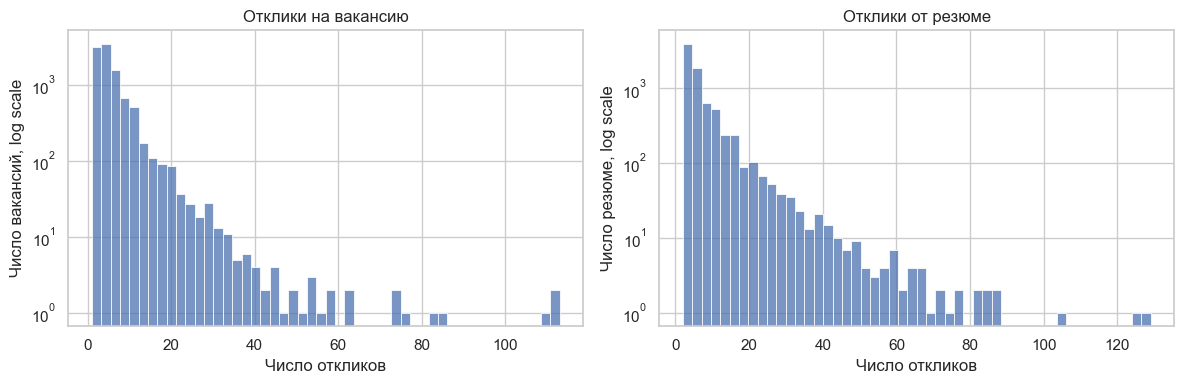

In [9]:
applies_per_vacancy = (
    applies.groupby("vacancy_id_hash").size().rename("applies_per_vacancy")
)
applies_per_cv = applies.groupby("cv_id_hash").size().rename("applies_per_cv")

behavior_summary = pd.DataFrame(
    [
        {
            "distribution": "applies per vacancy",
            "mean": applies_per_vacancy.mean(),
            "p50": applies_per_vacancy.quantile(0.50),
            "p75": applies_per_vacancy.quantile(0.75),
            "p90": applies_per_vacancy.quantile(0.90),
            "p99": applies_per_vacancy.quantile(0.99),
            "max": applies_per_vacancy.max(),
        },
        {
            "distribution": "applies per cv",
            "mean": applies_per_cv.mean(),
            "p50": applies_per_cv.quantile(0.50),
            "p75": applies_per_cv.quantile(0.75),
            "p90": applies_per_cv.quantile(0.90),
            "p99": applies_per_cv.quantile(0.99),
            "max": applies_per_cv.max(),
        },
    ]
)
display(behavior_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(applies_per_vacancy, bins=50, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Отклики на вакансию")
axes[0].set_xlabel("Число откликов")
axes[0].set_ylabel("Число вакансий, log scale")

sns.histplot(applies_per_cv, bins=50, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Отклики от резюме")
axes[1].set_xlabel("Число откликов")
axes[1].set_ylabel("Число резюме, log scale")
plt.tight_layout()
plt.show()

In [10]:
top_vacancies = (
    applies_per_vacancy.sort_values(ascending=False).head(10).reset_index()
    .merge(vacancies[['vacancy_id_hash', 'profession', 'group_profession', 'business_category', 'published_at_jittered']], on='vacancy_id_hash', how='left')
)
top_cv = (
    applies_per_cv.sort_values(ascending=False).head(10).reset_index()
    .merge(cv[['cv_id_hash', 'profession', 'group_profession', 'business_category', 'created_at_jittered']], on='cv_id_hash', how='left')
)

print('Самые массовые вакансии по числу откликов')
display(top_vacancies)
print('Самые активные резюме по числу откликов')
display(top_cv)

Самые массовые вакансии по числу откликов


,vacancy_id_hash,applies_per_vacancy,profession,group_profession,business_category,published_at_jittered
0,ff1db1502dd67d85,113,other,it-специалисты,Офисные,2026-02-23
1,5efbdf03d045eff8,111,менеджер по работе с клиентами,специалисты по продажам,Офисные,2026-03-03
2,2958e86f9ddeae26,109,оператор пк,специалисты по документообороту,Офисные,2026-01-19
3,7a09775a4b5739e3,84,менеджер по работе с клиентами,специалисты по продажам,Офисные,2026-02-09
4,a9dff6796a9fa304,82,менеджер по работе с маркетплейсами,cотрудники маркетинга и pr,Офисные,2026-02-01
5,0112f4f0ea9ed4f9,75,менеджер по работе с клиентами,специалисты по продажам,Офисные,2026-03-29
6,ed79e87742d061d5,73,упаковщик,работники складов,РиЛ,2026-01-15
7,05f288dae129ccca,73,сотрудник склада,работники складов,РиЛ,2026-01-06
8,7d123e8366f1a9f6,63,графический дизайнер,it-специалисты,Офисные,2026-03-06
9,35eadaf3945fdc80,62,упаковщик,работники складов,РиЛ,2026-01-12


Самые активные резюме по числу откликов


,cv_id_hash,applies_per_cv,profession,group_profession,business_category,created_at_jittered
0,a928f4b5e449ee1b,129,other,сотрудники hr,Офисные,2026-05-08
1,0a65749e66fb89fa,124,другая,другое,Другое,2026-05-08
2,b10af3b5905975ea,105,кладовщик,работники складов,РиЛ,2025-01-02
3,688a348856fdcf5d,88,smm-специалист,cотрудники маркетинга и pr,Офисные,2026-05-08
4,0607b3da1f0b99af,88,менеджер по работе с клиентами,специалисты по продажам,Офисные,2026-05-09
5,82c425ababd0d4ec,85,сотрудник склада,работники складов,РиЛ,2026-05-09
6,26539d1081e746e8,84,упаковщик,работники складов,РиЛ,2026-05-06
7,65979bf8771bcdbb,82,разнорабочий,строители и ремонтники,РиЛ,2026-05-09
8,5221c5a0a30ab4cb,81,администратор,административный персонал,РиЛ,2026-05-08
9,d8eecff104c4fe55,76,другая,другое,Другое,2025-01-02


## Маржинальные распределения CV и вакансий

Можно сравнить не только позитивные пары, но и общий состав двух сторон маркетплейса. Если резюме и вакансии сильно различаются по таксономиям, то модель и фильтры будут работать в условиях дисбаланса спроса и предложения.

Ниже для каждого поля считаются количества и доли значений в CV и вакансиях, разница долей в процентных пунктах, а также значения, которые есть только на одной стороне.

Для более подробного сравнения и вывода указываем параметр top_n

In [11]:
def compare_side_distribution(field: str, top_n: int = 15) -> pd.DataFrame:
    cv_counts = (
        cv[field]
        .astype('string')
        .fillna('<missing>')
        .value_counts(dropna=False)
        .rename('cv_count')
        .reset_index()
        .rename(columns={'index': field})
    )
    vacancy_counts = (
        vacancies[field]
        .astype('string')
        .fillna('<missing>')
        .value_counts(dropna=False)
        .rename('vacancy_count')
        .reset_index()
        .rename(columns={'index': field})
    )

    dist = cv_counts.merge(vacancy_counts, on=field, how='outer').fillna(0)
    dist['cv_count'] = dist['cv_count'].astype(int)
    dist['vacancy_count'] = dist['vacancy_count'].astype(int)
    dist['cv_pct'] = dist['cv_count'] / len(cv) * 100
    dist['vacancy_pct'] = dist['vacancy_count'] / len(vacancies) * 100
    dist['pct_diff_pp'] = dist['cv_pct'] - dist['vacancy_pct']
    dist['side_presence'] = np.select(
        [
            (dist['cv_count'] > 0) & (dist['vacancy_count'] > 0),
            (dist['cv_count'] > 0) & (dist['vacancy_count'] == 0),
            (dist['cv_count'] == 0) & (dist['vacancy_count'] > 0),
        ],
        ['both', 'cv_only', 'vacancy_only'],
        default='none',
    )
    return dist.sort_values('pct_diff_pp', key=lambda s: s.abs(), ascending=False).head(top_n)


print(
    '- pct_diff_pp: разница долей CV и вакансий в процентных пунктах, cv_pct - vacancy_pct\n'
    '- side_presence: где встречается значение: both, cv_only или vacancy_only\n'
)

distribution_fields = ['profession', 'group_profession', 'business_category', 'sfera']
for field in distribution_fields:
    print(f'Поле: {field}')
    display(compare_side_distribution(field, top_n=15))


- pct_diff_pp: разница долей CV и вакансий в процентных пунктах, cv_pct - vacancy_pct
- side_presence: где встречается значение: both, cv_only или vacancy_only

Поле: profession


,profession,cv_count,vacancy_count,cv_pct,vacancy_pct,pct_diff_pp,side_presence
14,другая,1403,0,17.590271,0.000000,17.590271,cv_only
55,фасовщик,225,957,2.820963,9.611329,-6.790366,both
0,other,1527,1235,19.144935,12.403334,6.741600,both
36,помощник руководителя,99,524,1.241224,5.262629,-4.021406,both
54,упаковщик,312,777,3.911735,7.803555,-3.891820,both
49,сотрудник склада,143,535,1.792879,5.373104,-3.580226,both
17,комплектовщик,208,538,2.607823,5.403234,-2.795410,both
18,курьер,320,665,4.012036,6.678718,-2.666682,both
43,разнорабочий,299,571,3.748746,5.734659,-1.985913,both
22,менеджер по продажам,176,82,2.206620,0.823541,1.383079,both


Поле: group_profession


,group_profession,cv_count,vacancy_count,cv_pct,vacancy_pct,pct_diff_pp,side_presence
19,работники складов,1301,3563,16.311434,35.783871,-19.472436,both
7,другое,1403,0,17.590271,0.000000,17.590271,cv_only
27,специалисты по документообороту,181,601,2.269308,6.035955,-3.766647,both
5,водители и курьеры,756,1190,9.478435,11.951391,-2.472956,both
28,специалисты по продажам,444,337,5.566700,3.384554,2.182147,both
1,cпециалисты службы поддержки,143,392,1.792879,3.936929,-2.144050,both
17,работники розничной торговли,504,444,6.318957,4.459174,1.859782,both
24,"сотрудники охраны, контроля и госорганов",179,366,2.244233,3.675806,-1.431573,both
26,сотрудники финансов и логистики,160,72,2.006018,0.723109,1.282909,both
16,работники кухни и пищевого производства,180,135,2.256770,1.355830,0.900940,both


Поле: business_category


,business_category,cv_count,vacancy_count,cv_pct,vacancy_pct,pct_diff_pp,side_presence
1,Другое,1746,201,21.890672,2.018680,19.871992,both
3,РиЛ,4006,6660,50.225677,66.887617,-16.661940,both
0,TTL,812,1263,10.180542,12.684544,-2.504002,both
2,Офисные,1412,1833,17.703109,18.409159,-0.706050,both


Поле: sfera


,sfera,cv_count,vacancy_count,cv_pct,vacancy_pct,pct_diff_pp,side_presence
6,"без опыта, студенты",3474,0,43.555667,0.000000,43.555667,cv_only
40,склады и хранилища,0,1690,0.000000,16.972984,-16.972984,vacancy_only
8,бытовые и персональные услуги,0,1311,0.000000,13.166616,-13.166616,vacancy_only
12,"доставка, грузоперевозки и логистика",0,1159,0.000000,11.640052,-11.640052,vacancy_only
3,административная работа,803,0,10.067703,0.000000,10.067703,cv_only
38,розничная и оптовая торговля,0,800,0.000000,8.034549,-8.034549,vacancy_only
33,продажи,632,0,7.923771,0.000000,7.923771,cv_only
47,"транспорт, логистика",576,0,7.221665,0.000000,7.221665,cv_only
30,пищевая промышленность,0,662,0.000000,6.648589,-6.648589,vacancy_only
41,строительство,392,0,4.914744,0.000000,4.914744,cv_only


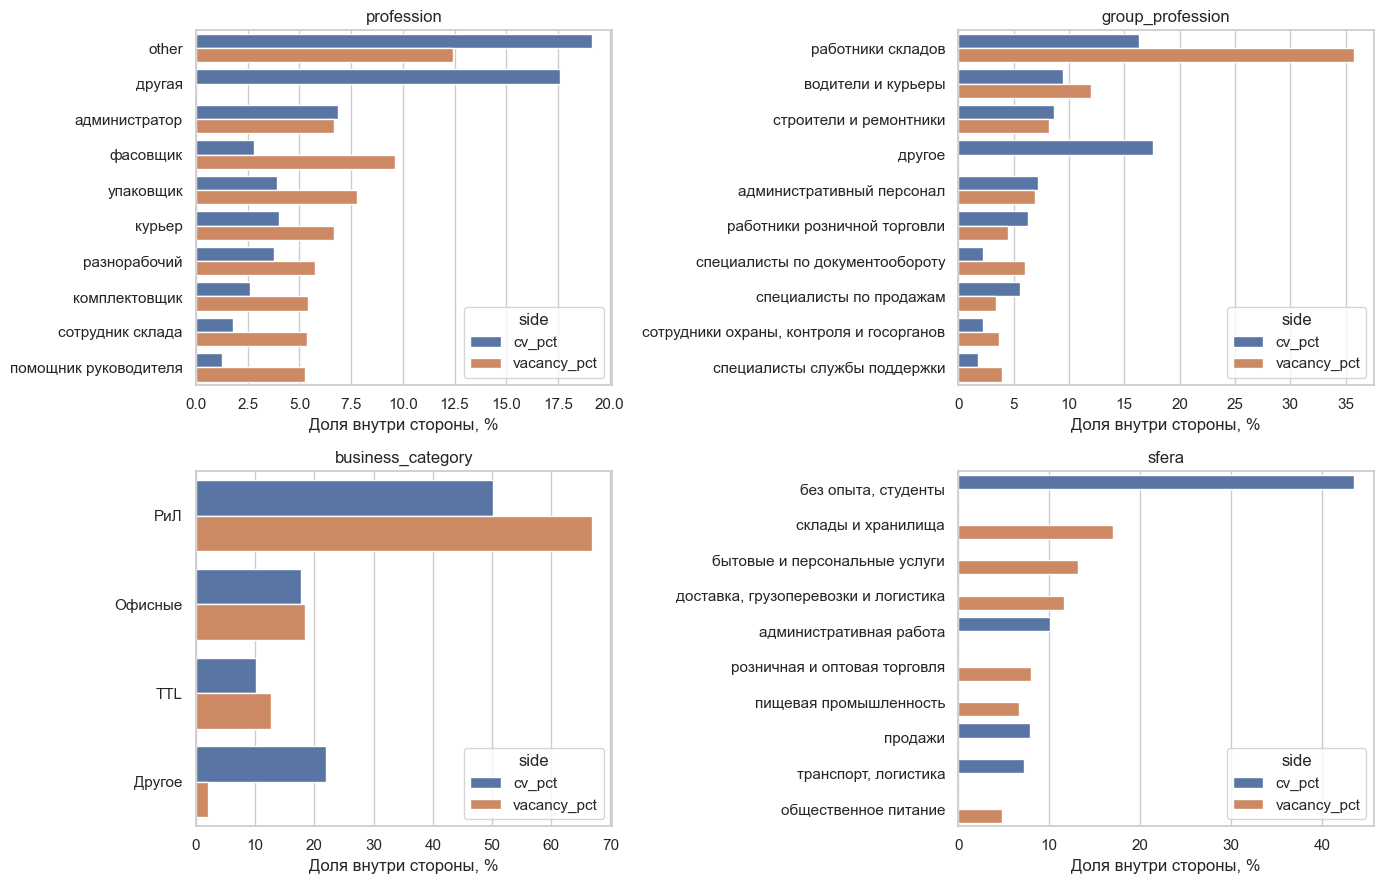

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, field in zip(axes, distribution_fields):
    top_values = (
        pd.concat([
            cv[field].astype('string').fillna('<missing>'),
            vacancies[field].astype('string').fillna('<missing>'),
        ])
        .value_counts()
        .head(10)
        .index
    )
    plot_df = pd.concat(
        [
            cv[field].astype('string').fillna('<missing>').value_counts(normalize=True).mul(100).rename('cv_pct'),
            vacancies[field].astype('string').fillna('<missing>').value_counts(normalize=True).mul(100).rename('vacancy_pct'),
        ],
        axis=1,
    ).fillna(0).loc[top_values].reset_index().rename(columns={'index': field})
    plot_long = plot_df.melt(id_vars=field, var_name='side', value_name='pct')
    sns.barplot(data=plot_long, y=field, x='pct', hue='side', ax=ax)
    ax.set_title(field)
    ax.set_xlabel('Доля внутри стороны, %')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


## Опыт и зарплатные выбросы

можно отдельно посмотреть опыт и ожидаемую зарплату. Это потенциальные признаки ранжирования, но у зарплаты есть много пропусков, отрицательные значения после джиттера и длинный правый хвост.

In [13]:
experience_side_by_side = pd.concat(
    [
        cv['experience_bucket'].astype('string').fillna('<missing>').value_counts(dropna=False).rename('cv_count'),
        vacancies['experience'].astype('string').fillna('<missing>').value_counts(dropna=False).rename('vacancy_count'),
    ],
    axis=1,
).fillna(0).astype(int).reset_index().rename(columns={'index': 'experience_value'})

experience_side_by_side['cv_pct'] = experience_side_by_side['cv_count'] / len(cv) * 100
experience_side_by_side['vacancy_pct'] = experience_side_by_side['vacancy_count'] / len(vacancies) * 100
display(experience_side_by_side.sort_values(['cv_count', 'vacancy_count'], ascending=False))


,experience_value,cv_count,vacancy_count,cv_pct,vacancy_pct
0,без опыта,3887,9031,48.733701,90.700010
1,есть опыт,2782,0,34.879639,0.000000
2,<missing>,1307,0,16.386660,0.000000
3,более 1 года,0,758,0.000000,7.612735
4,более 3 лет,0,136,0.000000,1.365873
5,более 5 лет,0,26,0.000000,0.261123
6,other,0,6,0.000000,0.060259


,rows,filled,missing_pct,min,p01,p25,median,p75,p99,max,negative_count,gt_500k_count
0,7976,2229,72.053661,-2411.0,-1345.68,41071.0,61555.0,98542.0,250652.16,1000214.0,45,6


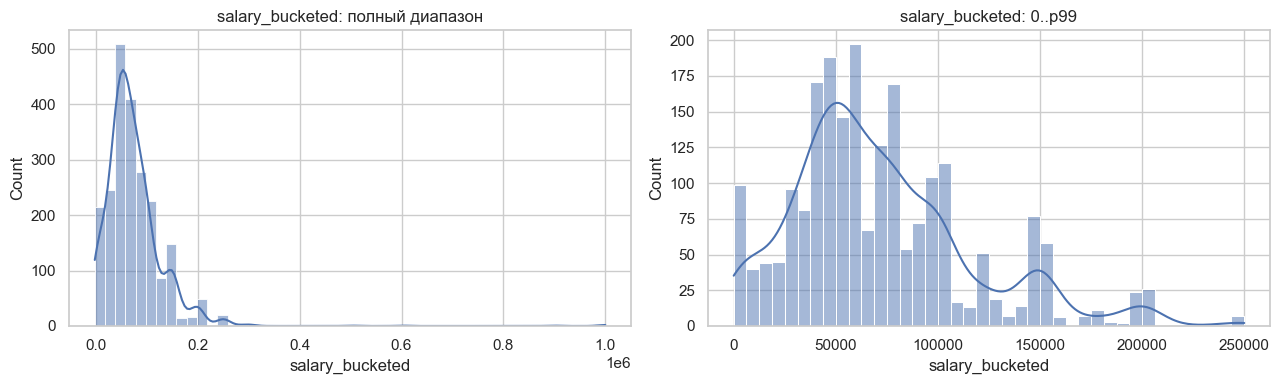

резюме с очень большой ожидаемой зарплатой и количество откликов на них


,cv_id_hash,user_id_hash,created_at_jittered,profession,group_profession,business_category,sfera,experience_bucket,education,federal_district,salary_bucketed,employment_type,schedule,applies_count
0,c72f425e53c43abf,a4a8b2bb408022ef,2026-05-05,other,сотрудники финансов и логистики,Офисные,продажи,есть опыт,высшее,Центральный федеральный округ,1000214.0,только основная работа,полный день,5
5,34171eeb25a81bfb,26a35d40a5201196,2026-05-09,комплектовщик,работники складов,РиЛ,"без опыта, студенты",без опыта,образование не указано,Центральный федеральный округ,999625.0,смешанный,свободный график,4
4,307223fb05819f92,aba76c83aaec5e39,2026-05-07,другая,другое,Другое,"без опыта, студенты",без опыта,среднее,Приволжский федеральный округ,998798.0,только подработка,свободный график,5
3,0143edd52f3b595a,b68dc91bf2056f94,2026-05-08,упаковщик,работники складов,РиЛ,"без опыта, студенты",без опыта,образование не указано,Центральный федеральный округ,898156.0,только подработка,сменный график,9
2,c9059d27080dfcee,ecbb55db482ae842,2026-05-05,разнорабочий,строители и ремонтники,РиЛ,"без опыта, студенты",без опыта,среднее,Сибирский федеральный округ,601821.0,смешанный,вахтовый метод,7
1,3cf72a04fa9f5ca4,dd8029322c1c4aba,2026-05-07,сварщик,строители и ремонтники,РиЛ,строительство,<NA>,среднее специальное,Уральский федеральный округ,501294.0,смешанный,вахтовый метод,2


отклики этих зарплатных выбросов, информация о вакансиях, на которые они откликались (первые 20)


,cv_id_hash,vacancy_id_hash,applied_at_jittered,profession,group_profession,business_category,sfera,experience,schedule,employment_type
14,0143edd52f3b595a,9ec02a6d5681e5e4,2026-03-10,менеджер по работе с клиентами,специалисты по продажам,Офисные,"фитнес-клубы, спа и салоны красоты",без опыта,гибкий,частичная занятость
17,0143edd52f3b595a,ff1db1502dd67d85,2026-03-13,other,it-специалисты,Офисные,архитектура и дизайн,без опыта,гибкий,частичная занятость
18,0143edd52f3b595a,3ff3df502f490f1c,2026-03-13,other,работники розничной торговли,РиЛ,"фитнес-клубы, спа и салоны красоты",без опыта,гибкий,частичная занятость
15,0143edd52f3b595a,7a09775a4b5739e3,2026-03-16,менеджер по работе с клиентами,специалисты по продажам,Офисные,продажа и управление недвижимостью,без опыта,гибкий,частичная занятость
16,0143edd52f3b595a,362a17123759b07c,2026-03-16,менеджер по работе с клиентами,специалисты по продажам,Офисные,"фитнес-клубы, спа и салоны красоты",без опыта,гибкий,частичная занятость
20,0143edd52f3b595a,3e0afe7dd0d65b5d,2026-03-17,маркировщик,работники складов,РиЛ,бытовые и персональные услуги,без опыта,гибкий,частичная занятость
22,0143edd52f3b595a,bc921b2ab70800d1,2026-04-17,помощник руководителя,специалисты по документообороту,Офисные,бытовые и персональные услуги,без опыта,гибкий,частичная занятость
21,0143edd52f3b595a,a7ac7ff5823cd3f4,2026-04-19,фасовщик,работники складов,РиЛ,склады и хранилища,без опыта,гибкий,частичная занятость
23,0143edd52f3b595a,2e037c91d63a5a57,2026-04-19,комплектовщик,работники складов,РиЛ,"доставка, грузоперевозки и логистика",без опыта,гибкий,частичная занятость
0,307223fb05819f92,f4222df8f99e8929,2026-03-24,помощник руководителя,специалисты по документообороту,Офисные,склады и хранилища,без опыта,гибкий,частичная занятость


In [14]:
salary = cv['salary_bucketed']
salary_summary = pd.DataFrame([
    {
        'rows': len(cv),
        'filled': int(salary.notna().sum()),
        'missing_pct': salary.isna().mean() * 100,
        'min': salary.min(),
        'p01': salary.quantile(0.01),
        'p25': salary.quantile(0.25),
        'median': salary.median(),
        'p75': salary.quantile(0.75),
        'p99': salary.quantile(0.99),
        'max': salary.max(),
        'negative_count': int((salary < 0).sum()),
        'gt_500k_count': int((salary > 500_000).sum()),
    }
])
display(salary_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=cv, x='salary_bucketed', bins=50, kde=True, ax=axes[0])
axes[0].set_title('salary_bucketed: полный диапазон')
axes[0].set_xlabel('salary_bucketed')

salary_cap = salary.quantile(0.99)
sns.histplot(data=cv[cv['salary_bucketed'].between(0, salary_cap)], x='salary_bucketed', bins=40, kde=True, ax=axes[1])
axes[1].set_title('salary_bucketed: 0..p99')
axes[1].set_xlabel('salary_bucketed')
plt.tight_layout()
plt.show()

print("резюме с очень большой ожидаемой зарплатой и количество откликов на них")

salary_outliers = (
    cv[cv['salary_bucketed'] > 500_000]
    .merge(applies.groupby('cv_id_hash').size().rename('applies_count'), on='cv_id_hash', how='left')
    .fillna({'applies_count': 0})
    .sort_values('salary_bucketed', ascending=False)
)
salary_outliers['applies_count'] = salary_outliers['applies_count'].astype(int)
display(salary_outliers)

print("отклики этих зарплатных выбросов, информация о вакансиях, на которые они откликались (первые 20)")

if not salary_outliers.empty:
    outlier_apply_examples = (
        applies[applies['cv_id_hash'].isin(salary_outliers['cv_id_hash'])]
        .merge(
            vacancies[['vacancy_id_hash', 'profession', 'group_profession', 'business_category', 'sfera', 'experience', 'schedule', 'employment_type']],
            on='vacancy_id_hash',
            how='left',
        )
        .sort_values(['cv_id_hash', 'applied_at_jittered'])
        .head(20)
    )
    display(outlier_apply_examples)


## Фильтры и таксономии

Проверяем, что будет, если использовать общие поля как жесткие exact-match фильтры. `oracle_recall_positive_pct` показывает долю исторических позитивных пар, которые такой фильтр сохранил бы. `mean_candidate_set` показывает средний размер множества CV-кандидатов на одну вакансию при exact match по этому полю.

In [15]:
filter_fields = ['profession', 'group_profession', 'business_category', 'sfera', 'schedule', 'employment_type']

positive_pairs = (
    applies[['cv_id_hash', 'vacancy_id_hash']]
    .merge(cv.add_prefix('cv_'), left_on='cv_id_hash', right_on='cv_cv_id_hash', how='left')
    .merge(vacancies.add_prefix('vac_'), left_on='vacancy_id_hash', right_on='vac_vacancy_id_hash', how='left')
)


def exact_filter_report(field: str) -> dict:
    left = positive_pairs[f'cv_{field}'].astype('string')
    right = positive_pairs[f'vac_{field}'].astype('string')
    known = left.notna() & right.notna()
    same = known & (left == right)

    cv_values = cv[field].astype('string')
    vacancy_values = vacancies[field].astype('string')
    cv_counts = cv_values.value_counts(dropna=False)
    candidate_sizes = vacancy_values.map(cv_counts).fillna(0).astype(int)

    return {
        'field': field,
        'known_positive_pairs_pct': known.mean() * 100,
        'oracle_recall_positive_pct': same.mean() * 100,
        'positives_kept': int(same.sum()),
        'mean_candidate_set': candidate_sizes.mean(),
        'median_candidate_set': candidate_sizes.median(),
        'p90_candidate_set': candidate_sizes.quantile(0.90),
        'vacancies_without_candidates_pct': (candidate_sizes == 0).mean() * 100,
    }


filter_report = pd.DataFrame([exact_filter_report(field) for field in filter_fields])
display(filter_report)

,field,known_positive_pairs_pct,oracle_recall_positive_pct,positives_kept,mean_candidate_set,median_candidate_set,p90_candidate_set,vacancies_without_candidates_pct
0,profession,100.0,15.972821,9074,368.172944,225.0,1527.0,5.282716
1,group_profession,100.0,29.245366,16614,735.738676,687.0,1301.0,0.803455
2,business_category,100.0,56.237568,31948,3077.699910,4006.0,4006.0,0.000000
3,sfera,100.0,0.089775,51,2.343477,0.0,0.0,97.308426
4,schedule,100.0,0.000000,0,0.000000,0.0,0.0,100.000000
5,employment_type,100.0,0.000000,0,0.000000,0.0,0.0,100.000000


- profession сильно жесткий фильтр: оставляет только 16% позитивов
- group_profession тоже теряет много: остается 29%
- business_category сохраняет 56%, но candidate set очень большой, около 3078 резюме
- sfera почти не работает как общий фильтр
- schedule и employment_type нельзя сравнивать напрямую, нужны правила совместимости


In [16]:
def vocabulary_table(field: str, top_n: int = 12) -> pd.DataFrame:
    cv_top = cv[field].astype('string').value_counts(dropna=False).head(top_n).rename('cv_count')
    vac_top = vacancies[field].astype('string').value_counts(dropna=False).head(top_n).rename('vacancy_count')
    return pd.concat([cv_top, vac_top], axis=1).fillna(0).astype(int).reset_index().rename(columns={'index': field})


for field in ['schedule', 'employment_type']:
    print(f'Словари поля {field}')
    display(vocabulary_table(field, top_n=20))

Словари поля schedule


,schedule,cv_count,vacancy_count
0,полный день,2851,0
1,свободный график,1898,0
2,сменный график,1292,0
3,неполный день,956,0
4,вахтовый метод,583,0
5,удалённая работа,396,0
6,гибкий,0,5674
7,сменный,0,2075
8,вахта,0,1152
9,фиксированный,0,1056


Словари поля employment_type


,employment_type,cv_count,vacancy_count
0,смешанный,3243,0
1,только основная работа,3108,0
2,только подработка,1625,0
3,частичная занятость,0,5411
4,полная занятость,0,4345
5,временная,0,196
6,other,0,5


## Embedding baseline

Сначала сравним cosine similarity для исторических позитивных пар и случайных негативов. Затем посчитаем exact top-K retrieval: для каждой вакансии берем все CV, считаем dot product чанками и проверяем, попали ли исторические позитивы в top-10/50/100.

,positive,random_negative
count,56809.000000,50000.000000
mean,0.560508,0.503129
std,0.091822,0.081093
min,0.244047,0.231340
1%,0.371046,0.338802
25%,0.492281,0.446175
50%,0.555927,0.496394
75%,0.628516,0.552646
99%,0.761344,0.711486
max,0.855538,0.815913


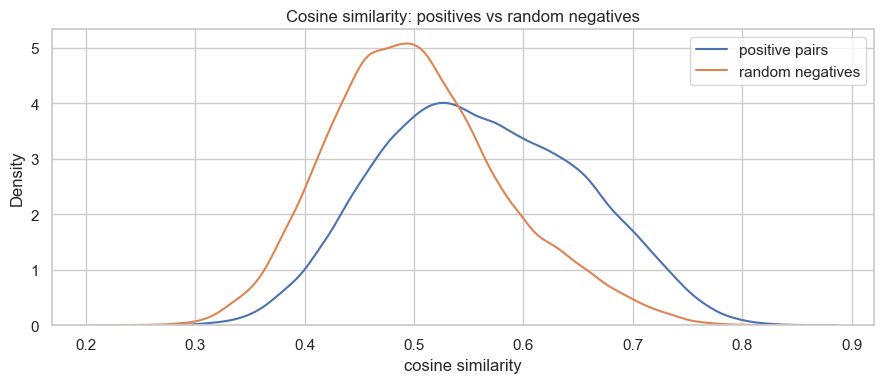

In [17]:
cv_index = pd.Series(np.arange(len(cv_embeddings)), index=cv_embeddings['cv_id_hash'])
vacancy_index = pd.Series(np.arange(len(vacancies_embeddings)), index=vacancies_embeddings['vacancy_id_hash'])

valid_applies = applies[
    applies['cv_id_hash'].isin(cv_index.index) & applies['vacancy_id_hash'].isin(vacancy_index.index)
].copy()
valid_applies['cv_idx'] = cv_index.loc[valid_applies['cv_id_hash']].to_numpy()
valid_applies['vacancy_idx'] = vacancy_index.loc[valid_applies['vacancy_id_hash']].to_numpy()

pos_cv_idx = valid_applies['cv_idx'].to_numpy()
pos_vacancy_idx = valid_applies['vacancy_idx'].to_numpy()
pos_sims = np.einsum('ij,ij->i', cv_matrix[pos_cv_idx], vacancy_matrix[pos_vacancy_idx])

rng = np.random.default_rng(42)
positive_pair_set = set(zip(pos_cv_idx.tolist(), pos_vacancy_idx.tolist()))
n_negatives = min(50_000, len(valid_applies))
neg_cv_idx = []
neg_vacancy_idx = []
while len(neg_cv_idx) < n_negatives:
    cv_sample = rng.integers(0, len(cv_matrix), size=n_negatives)
    vacancy_sample = rng.integers(0, len(vacancy_matrix), size=n_negatives)
    for cv_i, vacancy_i in zip(cv_sample, vacancy_sample):
        pair = (int(cv_i), int(vacancy_i))
        if pair not in positive_pair_set:
            neg_cv_idx.append(pair[0])
            neg_vacancy_idx.append(pair[1])
            if len(neg_cv_idx) >= n_negatives:
                break

neg_cv_idx = np.array(neg_cv_idx, dtype=np.int32)
neg_vacancy_idx = np.array(neg_vacancy_idx, dtype=np.int32)
neg_sims = np.einsum('ij,ij->i', cv_matrix[neg_cv_idx], vacancy_matrix[neg_vacancy_idx])

sim_stats = pd.concat(
    [
        pd.Series(pos_sims, name='positive').describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]),
        pd.Series(neg_sims, name='random_negative').describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]),
    ],
    axis=1,
)
display(sim_stats)

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(pos_sims, label='positive pairs', ax=ax)
sns.kdeplot(neg_sims, label='random negatives', ax=ax)
ax.set_title('Cosine similarity: positives vs random negatives')
ax.set_xlabel('cosine similarity')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
def exact_topk_retrieval(
    vacancy_matrix: np.ndarray,
    cv_matrix: np.ndarray,
    valid_pairs: pd.DataFrame,
    ks=(10, 50, 100),
    chunk_size: int = 256,
) -> pd.DataFrame:
    positives_by_vacancy = defaultdict(set)
    for vacancy_i, cv_i in zip(valid_pairs['vacancy_idx'].to_numpy(), valid_pairs['cv_idx'].to_numpy()):
        positives_by_vacancy[int(vacancy_i)].add(int(cv_i))

    max_k = max(ks)
    cv_matrix_t = np.ascontiguousarray(cv_matrix.T)
    hit_vacancies = {k: 0 for k in ks}
    recovered_pairs = {k: 0 for k in ks}
    positive_pair_total = sum(len(items) for items in positives_by_vacancy.values())
    vacancy_with_positive_total = len(positives_by_vacancy)

    for start in range(0, len(vacancy_matrix), chunk_size):
        stop = min(start + chunk_size, len(vacancy_matrix))
        sims = vacancy_matrix[start:stop] @ cv_matrix_t
        top_idx = np.argpartition(-sims, kth=max_k - 1, axis=1)[:, :max_k]
        top_scores = np.take_along_axis(sims, top_idx, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top_idx = np.take_along_axis(top_idx, order, axis=1)

        for row, vacancy_i in enumerate(range(start, stop)):
            positives = positives_by_vacancy.get(vacancy_i)
            if not positives:
                continue
            for k in ks:
                retrieved = set(map(int, top_idx[row, :k]))
                intersection = len(positives & retrieved)
                recovered_pairs[k] += intersection
                if intersection > 0:
                    hit_vacancies[k] += 1

        del sims, top_idx, top_scores, order
        gc.collect()

    return pd.DataFrame([
        {
            'K': k,
            'hit_rate_vacancies_with_positive_pct': hit_vacancies[k] / vacancy_with_positive_total * 100,
            'micro_recall_positive_pairs_pct': recovered_pairs[k] / positive_pair_total * 100,
            'recovered_positive_pairs': recovered_pairs[k],
        }
        for k in ks
    ])


topk_metrics = exact_topk_retrieval(
    vacancy_matrix=vacancy_matrix,
    cv_matrix=cv_matrix,
    valid_pairs=valid_applies,
    ks=(10, 50, 100),
    chunk_size=256,
)
display(topk_metrics)

,K,hit_rate_vacancies_with_positive_pct,micro_recall_positive_pairs_pct,recovered_positive_pairs
0,10,9.658862,1.957436,1112
1,50,24.677029,6.585224,3741
2,100,33.901897,10.070587,5721


## Финальные выводы

1. `applies` содержит только позитивные пары. Плотность позитивов около `0.0715%`, поэтому для обучения нужны негативы, но случайные негативы будут слишком легкими. Лучше добавлять hard negatives: близкие по embedding, совпадающие по крупной категории или попавшие в top-K кандидатов для вакансии

2. Жесткие exact-match фильтры по таксономиям опасны для recall. `profession` сохраняет около `16%` позитивов, `group_profession` около `29%`, `business_category` около `56%`. Эти поля лучше использовать как признаки, soft boosts или ограничения для части retrieval, но не как единственный обязательный фильтр

3. `schedule` и `employment_type` у CV и вакансий имеют разные словари - никакие поля не совпадают. Для них нужны маппинги, например `полный день` совместим с несколькими типами графика вакансии, а не с одной строкой

4. Embeddings валидные: размерность `1024`, нормы около `1`. Positive cosine выше random negative, но распределения заметно пересекаются. Значит embeddings годятся как генераторы кандидатов, но финальный ранжировщик должен учитывать структурные признаки, свежесть, активность и бизнес-правила

5. Во временных полях есть риски. Вакансии встречаются с датами с `2012-07-01`, отклики лежат в периоде `2025-11-06` - `2026-05-09`, а у многих пар `created_at_jittered` позже `applied_at_jittered`. Временной split и признаки возраста резюме/вакансии нужно проектировать осторожно и проверять без утечки будущего

6. Для baseline стоит начать с двух уровней: exact top-K по embeddings для генерации кандидатов, затем простой ранжировщик на cosine similarity плюс совместимость `business_category`, `group_profession`, опыта, образования, зарплаты и вручную заданных mappings для графика/занятости. Метрики: Recall@K для candidate generation, NDCG/MAP/HitRate@K для ранжирования и доля вакансий без рекомендаций

7. Маржинальные распределения CV и вакансий по `profession`, `group_profession`, `business_category` и `sfera` заметно различаются. Перед использованием этих полей как признаков или фильтров стоит нормализовать близкие значения вроде `другая`/`other` и проверить категории, которые существуют только на одной стороне.

8. `salary_bucketed` заполнен не для всех CV, имеет отрицательные значения после джиттера и редкие очень большие значения. Зарплату лучше использовать после обработки пропусков, клиппинга/бакетизации и отдельной проверки выбросов.